# 20 — ¿De dónde viene el error del modelo y del ingeniero?

Diagnóstico final del **mismo panel estricto de 2026 de 19**, sólo GAITANA. No reentrena, cambia predicciones ni utiliza este EDA para escoger otro ganador en test. Se estudian primero productos, después colores dentro de producto y variedades dentro de producto/color. Se conserva H1 separado de H1–H5 y se desglosa cada horizonte.

Un WAPE alto no implica aportar mucho al error de la finca: un grupo pequeño puede tener un porcentaje enorme. Por eso se distinguen **WAPE del grupo**, **participación en el error absoluto** y **aporte al WAPE total en puntos porcentuales**. Los aportes suman exactamente el WAPE del panel; los porcentajes de WAPE de distintos grupos no se suman.

El sesgo usa estimado menos real: positivo sobreestima, negativo subestima. Se muestran sobreestimaciones y subestimaciones por separado para exponer su compensación. Las semanas objetivo repetidas entre orígenes son casos de pronóstico, no producción física única. El análisis es exploratorio del test ya observado; las asociaciones no prueban causas agronómicas.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DATA=ROOT/'Datos_analiticos_proyecto'; OUT=DATA/'eda_origen_error'; OUT.mkdir(exist_ok=True)
FIG=ROOT/'Trabajo escrito/Figuras_resultados'; FIG.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad','origen','semana_objetivo','horizonte']
d=pd.read_parquet(DATA/'revision_clima_finca/comparacion_clima_curvas_2026.parquet')
d=d.loc[d.grupo_comparacion.eq('principal_estricta_nominal')].copy()
assert d.finca.eq('GAITANA').all() and not d.duplicated(KEY).any()
assert d.modelo_seleccionado.nunique()==1
d['Modelo']=d.Seleccion_pre2026;d['Ingeniero']=d.ingeniero
b=pd.read_parquet(DATA/'modelo_con_proyecciones_teoricas/base_analitica_proyecciones.parquet')
ctx=['media_4','media_8','desv_4','tendencia_4_8','produccion_lag1','observaciones_previas','motivo_cobertura']
d=d.merge(b[KEY+ctx],on=KEY,how='left',validate='one_to_one',indicator=True)
assert d._merge.eq('both').all();d=d.drop(columns='_merge')
assert np.isfinite(d[['y','Modelo','Ingeniero']]).all().all() and d.y.ge(0).all()
d['mes']=d.origen.dt.to_period('M').astype(str)
d['ruta']=np.where(d.curva_completa,'Teoría completa','Respaldo de producción reciente')
cv=d.desv_4/d.media_4.where(d.media_4.gt(0))
d['variabilidad_previa']=pd.cut(cv,[-np.inf,.25,.5,np.inf],labels=['Baja: CV ≤ 0,25','Media: 0,25–0,50','Alta: CV > 0,50']).astype('string').fillna('Sin referencia')
# Diagnóstico EX POST: usa el objetivo real; nunca es predictor disponible al origen.
ratio=d.y/d.media_4.where(d.media_4.gt(0))
d['cambio_real_expost']=pd.cut(ratio,[-np.inf,.5,1.5,np.inf],labels=['Caída: real ≤ 0,5 × media4','Dentro de 0,5–1,5 × media4','Subida: real > 1,5 × media4']).astype('string').fillna('Sin referencia')
PANELES={'H1':d.loc[d.horizonte.eq(1)],'H1–H5':d}
PANELES.update({f'H{h}':d.loc[d.horizonte.eq(h)] for h in range(2,6)})
METODOS=['Modelo','Ingeniero'];pd.set_option('display.max_columns',30)
print('Candidato congelado:',d.modelo_seleccionado.iloc[0],'; casos:',len(d),'; orígenes:',d.origen.min().date(),d.origen.max().date())

Candidato congelado: Sin_clima ; casos: 15838 ; orígenes: 2026-01-12 2026-08-31


## 1. Descomposición exacta y soporte

Para cada grupo, aporte al WAPE total = 100 × error absoluto del grupo / producción real del panel. La diferencia «aporte modelo − aporte ingeniero» positiva identifica dónde el modelo pierde frente al ingeniero. Su suma reconstruye la diferencia global de WAPE.

El WAPE de un grupo sin volumen real queda sin definir, aunque sus errores sí aportan al total. No se añaden constantes al denominador. El soporte bajo se marca con menos de 20 casos o de 8 semanas objetivo; es una alerta descriptiva, no una prueba de significancia. Se conservan todos los grupos, incluso los pequeños.

In [2]:
def tabla(panel,g,dims):
    filas=[]; total_real=g.y.sum()
    for metodo in METODOS:
        z=g.assign(error=g[metodo]-g.y)
        z['absoluto']=z.error.abs();z['sobre']=z.error.clip(lower=0);z['sub']=(-z.error).clip(lower=0)
        total_error=z.absoluto.sum()
        for clave,t in z.groupby(dims,dropna=False,observed=True):
            if not isinstance(clave,tuple):clave=(clave,)
            real=t.y.sum(); ae=t.absoluto.sum();neto=t.error.sum()
            filas.append(dict(zip(dims,clave))|{'panel':panel,'metodo':metodo,'casos':len(t),'origenes':t.origen.nunique(),'semanas_objetivo':t.semana_objetivo.nunique(),'real':real,'estimado':t[metodo].sum(),'error_absoluto':ae,'error_neto':neto,'sobre_tallos':t.sobre.sum(),'sub_tallos':t['sub'].sum(),'MAE':ae/len(t),'WAPE_pct':100*ae/real if real>0 else np.nan,'sesgo_pct':100*neto/real if real>0 else np.nan,'peso_real_pct':100*real/total_real,'participacion_error_pct':100*ae/total_error if total_error>0 else 0,'aporte_WAPE_pp':100*ae/total_real,'aporte_sobre_pp':100*t.sobre.sum()/total_real,'aporte_sub_pp':100*t['sub'].sum()/total_real,'soporte_bajo':len(t)<20 or t.semana_objetivo.nunique()<8})
    out=pd.DataFrame(filas)
    for metodo in METODOS:
        t=out.loc[out.metodo.eq(metodo)];e=g[metodo]-g.y
        assert t.casos.sum()==len(g)
        assert np.isclose(t.aporte_WAPE_pp.sum(),100*e.abs().sum()/g.y.sum())
        assert np.allclose(t.aporte_WAPE_pp,t.aporte_sobre_pp+t.aporte_sub_pp)
        assert np.isclose(t.error_neto.sum(),e.sum())
    return out

niveles={'Producto':['producto'],'Color':['producto','color'],'Variedad':['producto','color','variedad'],'Mes':['mes'],'Ruta':['ruta'],'Variabilidad':['variabilidad_previa'],'Cambio_expost':['cambio_real_expost'],'Producto_mes':['producto','mes'],'Producto_ruta':['producto','ruta'],'Producto_variabilidad':['producto','variabilidad_previa'],'Producto_cambio':['producto','cambio_real_expost']}
tablas={nombre:pd.concat([tabla(p,g,dims) for p,g in PANELES.items()],ignore_index=True) for nombre,dims in niveles.items()}
globales=[]
for p,g in PANELES.items():
    for m in METODOS:
        e=g[m]-g.y
        globales.append({'panel':p,'metodo':m,'casos':len(g),'WAPE_pct':100*e.abs().sum()/g.y.sum(),'sesgo_pct':100*e.sum()/g.y.sum(),'MAE':e.abs().mean(),'sobre_pp':100*e.clip(lower=0).sum()/g.y.sum(),'sub_pp':100*(-e).clip(lower=0).sum()/g.y.sum()})
globales=pd.DataFrame(globales);display(globales)
comparaciones={}
for nombre,dims in niveles.items():
    t=tablas[nombre]
    cols=dims+['panel']
    a=t.loc[t.metodo.eq('Modelo')].drop(columns='metodo');b=t.loc[t.metodo.eq('Ingeniero'),cols+['WAPE_pct','sesgo_pct','aporte_WAPE_pp','participacion_error_pct']]
    c=a.merge(b,on=cols,validate='one_to_one',suffixes=('_modelo','_ingeniero'))
    c['exceso_modelo_pp']=c.aporte_WAPE_pp_modelo-c.aporte_WAPE_pp_ingeniero
    comparaciones[nombre]=c

,panel,metodo,casos,WAPE_pct,sesgo_pct,MAE,sobre_pp,sub_pp
0,H1,Modelo,3413,15.659471,-1.233628,1978.157494,7.212921,8.446549
1,H1,Ingeniero,3413,17.090192,-7.562675,2158.891005,4.763758,12.326434
2,H1–H5,Modelo,15838,19.458413,-2.423741,2496.165835,8.517336,10.941077
3,H1–H5,Ingeniero,15838,19.735606,-9.745207,2531.724839,4.995200,14.740407
4,H2,Modelo,3289,17.373907,-2.395217,2222.803988,7.489345,9.884562
5,H2,Ingeniero,3289,19.282910,-8.170824,2467.040438,5.556043,13.726867
6,H3,Modelo,3166,20.385561,-2.703129,2611.504548,8.841216,11.544345
7,H3,Ingeniero,3166,20.315054,-9.460602,2602.472205,5.427226,14.887828
8,H4,Modelo,3045,21.955053,-3.266015,2843.244081,9.344519,12.610534
9,H4,Ingeniero,3045,20.910523,-11.322686,2707.974384,4.793919,16.116604


## 2. Productos: dónde se concentra el problema

Las barras comparan aportes al WAPE, no sólo tasas locales. Un producto puede dominar el error por su volumen aunque su WAPE no sea el más alto. La tabla conserva ambas lecturas y el sesgo. El mapa por horizonte usa WAPE del producto: positivo significa que el modelo tiene mayor error porcentual que el ingeniero en ese segmento.

H1


,producto,casos,peso_real_pct,WAPE_pct_modelo,WAPE_pct_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,exceso_modelo_pp,soporte_bajo
5,MINICARNATION,979,60.339,14.333,14.534,-1.792,-6.858,8.648,8.769,-0.121,False
3,CARNATION,1258,18.520,18.909,20.170,-1.242,-7.851,3.502,3.736,-0.234,False
7,SOLOMIO,396,11.344,15.168,18.766,0.299,-9.635,1.721,2.129,-0.408,False
6,RAFFINE,203,6.037,15.958,25.577,-0.533,-9.408,0.963,1.544,-0.581,False
8,STAR,35,1.019,16.743,19.103,-0.827,-17.004,0.171,0.195,-0.024,False
2,BARBATUS,165,0.592,25.455,29.201,4.069,-0.752,0.151,0.173,-0.022,False
10,TRACHELIUM,33,0.290,34.631,41.928,-2.882,-24.165,0.100,0.122,-0.021,False
11,VERONICA,66,0.411,22.146,26.536,2.930,-7.909,0.091,0.109,-0.018,False
12,VERONICA SPRAY,66,0.381,22.996,23.722,3.863,-3.335,0.088,0.090,-0.003,False
4,GREEN BALL,33,0.608,13.931,16.104,2.824,-1.386,0.085,0.098,-0.013,False


H1–H5


,producto,casos,peso_real_pct,WAPE_pct_modelo,WAPE_pct_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,exceso_modelo_pp,soporte_bajo
18,MINICARNATION,4567,60.784,17.668,17.752,-4.543,-9.135,10.740,10.790,-0.051,False
16,CARNATION,5825,18.311,23.395,22.430,-0.780,-8.858,4.284,4.107,0.177,False
20,SOLOMIO,1860,11.218,18.201,18.539,2.234,-12.020,2.042,2.080,-0.038,False
19,RAFFINE,945,6.027,22.987,29.359,0.039,-13.766,1.385,1.769,-0.384,False
15,BARBATUS,775,0.594,33.752,28.535,8.818,-2.381,0.201,0.170,0.031,False
21,STAR,158,0.966,18.229,20.750,1.517,-19.514,0.176,0.200,-0.024,False
23,TRACHELIUM,148,0.294,41.873,47.357,-5.239,-32.118,0.123,0.139,-0.016,False
25,VERONICA SPRAY,310,0.379,30.274,26.165,7.931,-6.933,0.115,0.099,0.016,False
24,VERONICA,310,0.406,28.067,34.389,5.681,-17.882,0.114,0.140,-0.026,False
17,GREEN BALL,155,0.592,19.066,18.537,9.900,3.056,0.113,0.110,0.003,False


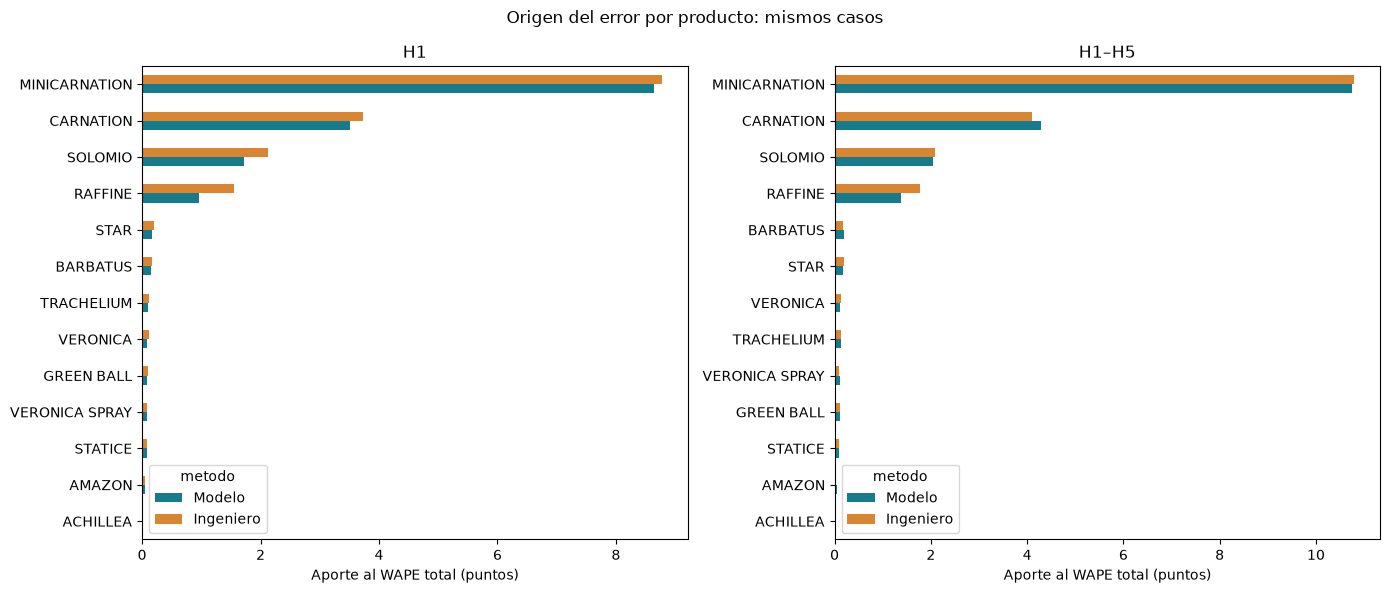

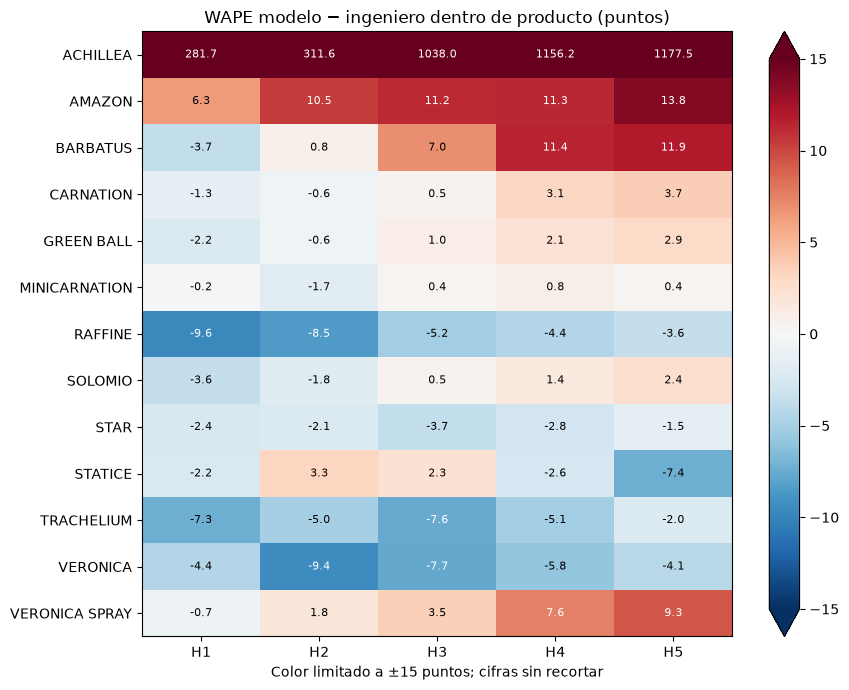

In [2]:
for p in ['H1','H1–H5']:
    t=comparaciones['Producto'].query('panel == @p').sort_values('aporte_WAPE_pp_modelo',ascending=False)
    print(p);display(t[['producto','casos','peso_real_pct','WAPE_pct_modelo','WAPE_pct_ingeniero','sesgo_pct_modelo','sesgo_pct_ingeniero','aporte_WAPE_pp_modelo','aporte_WAPE_pp_ingeniero','exceso_modelo_pp','soporte_bajo']].round(3))
fig,axes=plt.subplots(1,2,figsize=(14,6))
for ax,p in zip(axes,['H1','H1–H5']):
    t=tablas['Producto'].query('panel == @p').pivot(index='producto',columns='metodo',values='aporte_WAPE_pp')
    t=t.loc[t.max(axis=1).sort_values().index]
    t[METODOS].plot.barh(ax=ax,color=['#167b8c','#d98531']);ax.set_title(p);ax.set_xlabel('Aporte al WAPE total (puntos)');ax.set_ylabel('')
fig.suptitle('Origen del error por producto: mismos casos');fig.tight_layout();fig.savefig(FIG/'error_aporte_productos.png',dpi=170);plt.show()
c=comparaciones['Producto'].loc[lambda t:t.panel.ne('H1–H5')].copy()
c['diferencia_WAPE']=c.WAPE_pct_modelo-c.WAPE_pct_ingeniero
mat=c.pivot(index='producto',columns='panel',values='diferencia_WAPE').reindex(columns=[f'H{i}' for i in range(1,6)])
fig,ax=plt.subplots(figsize=(9,7));limit=15  # Saturación visual explícita; las cifras anotadas conservan el valor real.
im=ax.imshow(mat,cmap='RdBu_r',vmin=-limit,vmax=limit,aspect='auto')
ax.set_xticks(range(5),mat.columns);ax.set_yticks(range(len(mat)),mat.index)
for i in range(len(mat)):
    for j in range(5):
        if np.isfinite(mat.iloc[i,j]):ax.text(j,i,f'{mat.iloc[i,j]:.1f}',ha='center',va='center',fontsize=8,color='white' if abs(mat.iloc[i,j])>7.5 else 'black')
ax.set_title('WAPE modelo − ingeniero dentro de producto (puntos)');ax.set_xlabel('Color limitado a ±15 puntos; cifras sin recortar');fig.colorbar(im,ax=ax,extend='both');fig.tight_layout();fig.savefig(FIG/'error_producto_horizonte.png',dpi=170);plt.show()

## 3. Colores y variedades sin mezclar identidades

Color se interpreta dentro de producto; variedad dentro de producto y color. Los gráficos muestran los doce grupos con mayor aporte entre ambos métodos, no una selección favorable a uno de ellos. Las tablas exportadas contienen todos los grupos y todos los horizontes. Se listan aparte los grupos que más explican la desventaja del modelo; no equivale a recomendar un modelo por variedad usando este test.

Color H1 mayor aporte del modelo


,producto,color,casos,semanas_objetivo,WAPE_pct_modelo,WAPE_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,soporte_bajo
40,MINICARNATION,ORANGE,76,33,17.846,18.694,1.099,1.151,-5.364,-12.673,False
37,MINICARNATION,HOT PINK,66,33,14.919,14.872,1.075,1.072,-4.696,-6.106,False
39,MINICARNATION,LIGHT PINK,99,33,16.263,14.915,1.021,0.936,0.053,-0.256,False
43,MINICARNATION,RED,66,33,13.201,13.309,0.789,0.795,-1.536,-4.849,False
44,MINICARNATION,WHITE,99,33,14.571,16.763,0.763,0.877,0.907,-9.527,False
45,MINICARNATION,YELLOW,66,33,13.125,13.746,0.694,0.727,-2.601,-6.113,False
38,MINICARNATION,LAVENDER,33,33,13.454,15.002,0.498,0.555,-2.852,-13.258,False
42,MINICARNATION,PURPLE,33,33,15.172,10.114,0.497,0.331,-3.461,-4.353,False
26,CARNATION,WHITE,139,33,20.497,22.268,0.454,0.494,-5.262,-9.197,False
31,MINICARNATION,BICOLOR RED,66,33,11.387,12.258,0.361,0.389,0.626,-4.217,False


Mayor desventaja frente al ingeniero


,producto,color,casos,exceso_modelo_pp,soporte_bajo
42,MINICARNATION,PURPLE,33,0.165744,False
39,MINICARNATION,LIGHT PINK,99,0.084639,False
18,CARNATION,HOT PINK,33,0.042605,False
20,CARNATION,LIGHT PINK,66,0.040137,False
41,MINICARNATION,PEACH,44,0.024790,False
22,CARNATION,PEACH,99,0.024717,False
55,SOLOMIO,HOT PINK,33,0.023462,False
24,CARNATION,RED,106,0.022298,False


Color H1–H5 mayor aporte del modelo


,producto,color,casos,semanas_objetivo,WAPE_pct_modelo,WAPE_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,soporte_bajo
113,MINICARNATION,HOT PINK,310,34,18.796,16.260,1.372,1.187,-12.016,-6.813,False
115,MINICARNATION,LIGHT PINK,465,34,21.099,20.141,1.320,1.260,1.688,-1.349,False
116,MINICARNATION,ORANGE,350,34,18.815,21.763,1.168,1.351,-8.450,-15.913,False
119,MINICARNATION,RED,310,34,17.697,14.367,1.047,0.850,-3.373,-6.574,False
120,MINICARNATION,WHITE,465,34,19.370,21.259,1.019,1.119,1.313,-12.708,False
121,MINICARNATION,YELLOW,310,34,17.480,18.471,0.941,0.995,-6.816,-8.087,False
118,MINICARNATION,PURPLE,155,34,20.022,12.016,0.667,0.400,-10.576,-6.605,False
102,CARNATION,WHITE,648,34,25.186,25.769,0.550,0.563,-4.466,-12.483,False
114,MINICARNATION,LAVENDER,155,34,13.731,20.531,0.512,0.766,-7.209,-19.364,False
126,RAFFINE,LIGHT PINK,155,34,22.325,29.670,0.465,0.618,-7.616,-19.953,False


Mayor desventaja frente al ingeniero


,producto,color,casos,exceso_modelo_pp,soporte_bajo
118,MINICARNATION,PURPLE,155,0.266724,False
119,MINICARNATION,RED,310,0.197043,False
113,MINICARNATION,HOT PINK,310,0.185088,False
96,CARNATION,LIGHT PINK,310,0.124828,False
94,CARNATION,HOT PINK,155,0.080874,False
136,SOLOMIO,WHITE,155,0.068776,False
115,MINICARNATION,LIGHT PINK,465,0.059937,False
105,MINICARNATION,BICOLOR PINK,310,0.050016,False


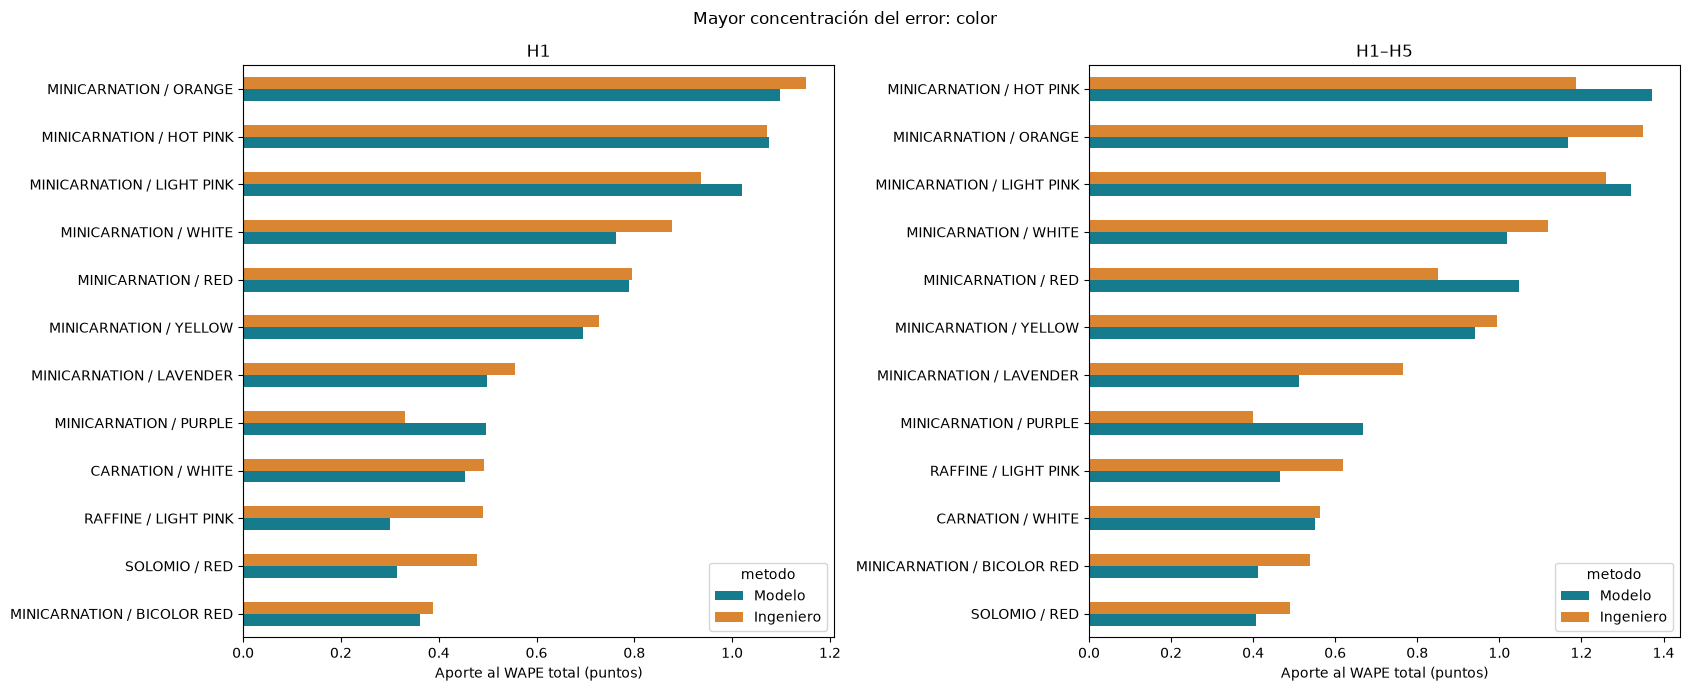

Variedad H1 mayor aporte del modelo


,producto,color,variedad,casos,semanas_objetivo,WAPE_pct_modelo,WAPE_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,soporte_bajo
79,MINICARNATION,ORANGE,UCHUVA,33,33,18.404,17.499,0.957,0.910,-6.589,-12.155,False
71,MINICARNATION,HOT PINK,LORENZO,33,33,16.335,16.114,0.669,0.660,-6.269,-6.507,False
74,MINICARNATION,LIGHT PINK,ACADEMY,33,33,19.151,16.364,0.627,0.535,0.191,6.786,False
88,MINICARNATION,YELLOW,CAESAR,33,33,13.653,14.577,0.506,0.541,-3.671,-10.278,False
73,MINICARNATION,LAVENDER,NENUFAR,33,33,13.454,15.002,0.498,0.555,-2.852,-13.258,False
82,MINICARNATION,PURPLE,EPSILON,33,33,15.172,10.114,0.497,0.331,-3.461,-4.353,False
84,MINICARNATION,RED,DRACULA,33,33,12.895,12.161,0.439,0.414,-0.566,-8.412,False
72,MINICARNATION,HOT PINK,PIGEON,33,33,13.059,13.239,0.407,0.413,-2.629,-5.579,False
83,MINICARNATION,RED,ARAGON,33,33,13.607,14.826,0.350,0.382,-2.818,-0.141,False
86,MINICARNATION,WHITE,NIMBUS,33,33,14.513,15.005,0.332,0.344,0.393,-11.391,False


Mayor desventaja frente al ingeniero


,producto,color,variedad,casos,exceso_modelo_pp,soporte_bajo
82,MINICARNATION,PURPLE,EPSILON,33,0.165744,False
74,MINICARNATION,LIGHT PINK,ACADEMY,33,0.091178,False
79,MINICARNATION,ORANGE,UCHUVA,33,0.047089,False
27,CARNATION,HOT PINK,ZEPPELIN,33,0.042605,False
31,CARNATION,LIGHT PINK,ILUSION,33,0.034806,False
84,MINICARNATION,RED,DRACULA,33,0.024952,False
101,SOLOMIO,HOT PINK,IMRE,33,0.023462,False
37,CARNATION,PEACH,APPLE TEA,33,0.022753,False


Variedad H1–H5 mayor aporte del modelo


,producto,color,variedad,casos,semanas_objetivo,WAPE_pct_modelo,WAPE_pct_ingeniero,aporte_WAPE_pp_modelo,aporte_WAPE_pp_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,soporte_bajo
202,MINICARNATION,ORANGE,UCHUVA,155,34,17.978,20.431,0.947,1.077,-11.118,-15.322,False
194,MINICARNATION,HOT PINK,LORENZO,155,34,19.935,16.239,0.826,0.673,-15.455,-4.031,False
197,MINICARNATION,LIGHT PINK,ACADEMY,155,34,21.537,19.379,0.697,0.627,-1.220,11.886,False
211,MINICARNATION,YELLOW,CAESAR,155,34,18.132,19.701,0.685,0.744,-8.677,-15.589,False
205,MINICARNATION,PURPLE,EPSILON,155,34,20.022,12.016,0.667,0.400,-10.576,-6.605,False
207,MINICARNATION,RED,DRACULA,155,34,16.606,13.433,0.565,0.457,-3.193,-10.358,False
195,MINICARNATION,HOT PINK,PIGEON,155,34,17.299,16.286,0.546,0.514,-7.497,-10.470,False
196,MINICARNATION,LAVENDER,NENUFAR,155,34,13.731,20.531,0.512,0.766,-7.209,-19.364,False
206,MINICARNATION,RED,ARAGON,155,34,19.173,15.631,0.482,0.393,-3.616,-1.454,False
218,RAFFINE,LIGHT PINK,THIA,155,34,22.325,29.670,0.465,0.618,-7.616,-19.953,False


Mayor desventaja frente al ingeniero


,producto,color,variedad,casos,exceso_modelo_pp,soporte_bajo
205,MINICARNATION,PURPLE,EPSILON,155,0.266724,False
194,MINICARNATION,HOT PINK,LORENZO,155,0.153159,False
207,MINICARNATION,RED,DRACULA,155,0.107972,False
206,MINICARNATION,RED,ARAGON,155,0.089071,False
150,CARNATION,HOT PINK,ZEPPELIN,155,0.080874,False
197,MINICARNATION,LIGHT PINK,ACADEMY,155,0.069824,False
230,SOLOMIO,WHITE,ARD,155,0.068776,False
153,CARNATION,LIGHT PINK,DONCEL,155,0.062790,False


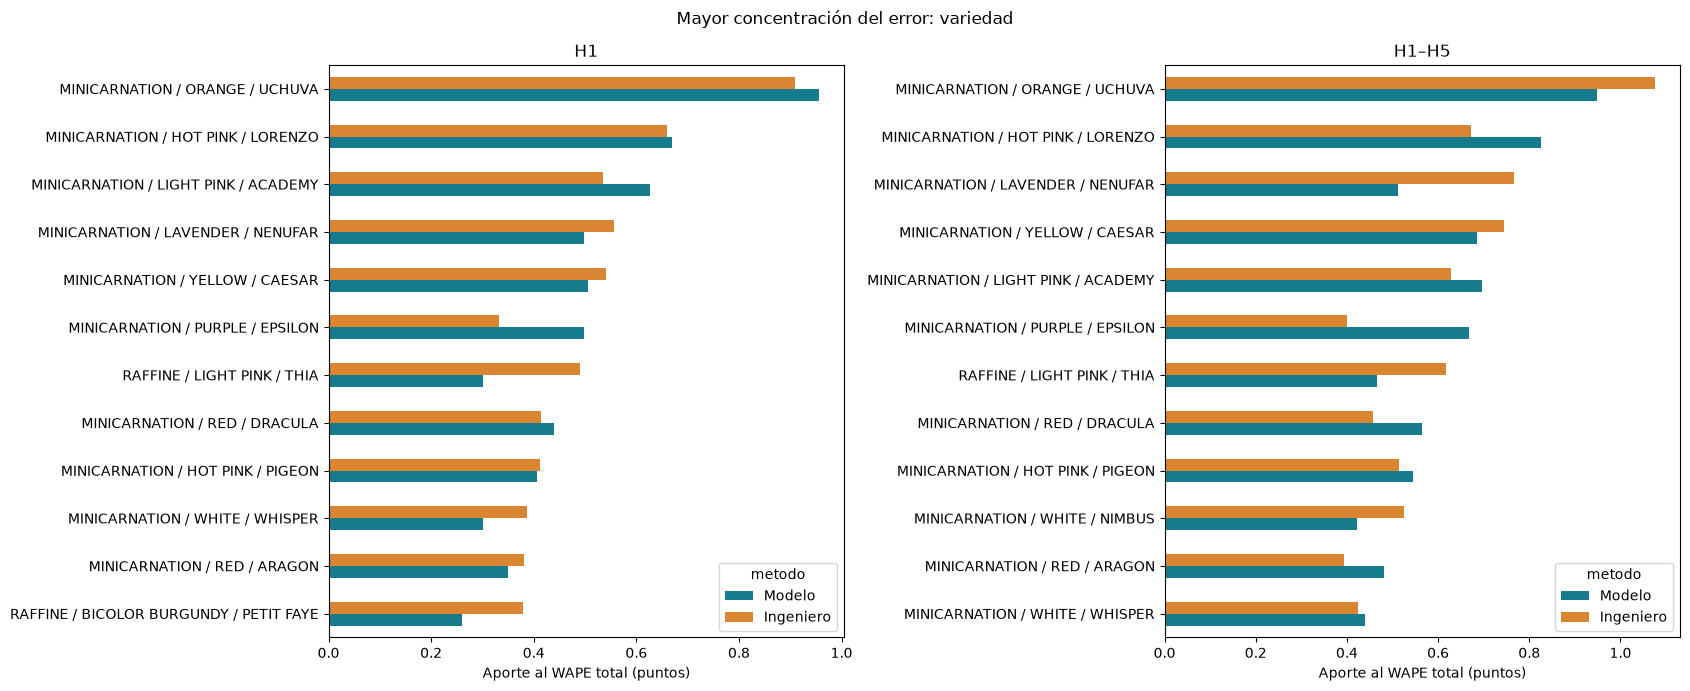

In [4]:
for nivel in ['Color','Variedad']:
    dims=niveles[nivel]
    for p in ['H1','H1–H5']:
        c=comparaciones[nivel].query('panel == @p').sort_values('aporte_WAPE_pp_modelo',ascending=False)
        print(nivel,p,'mayor aporte del modelo')
        display(c[dims+['casos','semanas_objetivo','WAPE_pct_modelo','WAPE_pct_ingeniero','aporte_WAPE_pp_modelo','aporte_WAPE_pp_ingeniero','sesgo_pct_modelo','sesgo_pct_ingeniero','soporte_bajo']].head(15).round(3))
        print('Mayor desventaja frente al ingeniero')
        display(c.sort_values('exceso_modelo_pp',ascending=False)[dims+['casos','exceso_modelo_pp','soporte_bajo']].head(8))
    fig,axes=plt.subplots(1,2,figsize=(17,7))
    for ax,p in zip(axes,['H1','H1–H5']):
        t=tablas[nivel].query('panel == @p').copy();t['grupo']=t[dims].astype(str).agg(' / '.join,axis=1)
        t=t.pivot(index='grupo',columns='metodo',values='aporte_WAPE_pp')
        idx=t.max(axis=1).nlargest(12).index;t=t.loc[idx];t=t.loc[t.max(axis=1).sort_values().index]
        t[METODOS].plot.barh(ax=ax,color=['#167b8c','#d98531']);ax.set_title(p);ax.set_xlabel('Aporte al WAPE total (puntos)');ax.set_ylabel('')
    fig.suptitle('Mayor concentración del error: '+nivel.lower());fig.tight_layout();fig.savefig(FIG/f'error_aporte_{nivel.lower()}.png',dpi=160);plt.show()

## 4. Buscar explicaciones: concentración temporal, cambios y cobertura

Se contrasta error con ruta de teoría/respaldo y variabilidad de las cuatro semanas previas, conocidas al emitir. Se informa además si la producción real no superó la mitad o superó 1,5 veces la media previa: es una descripción **posterior al resultado**, no una variable para pronosticar ni una causa demostrada. Estos umbrales son descriptivos y no se optimizan buscando mejorar el test.

Se repite el diagnóstico dentro de producto para evitar atribuir al respaldo o a la volatilidad lo que podría ser mezcla de productos. Aun así, no es un experimento causal. La curva completa suele tener poco soporte; un error alto allí no prueba que usar curvas lo cause.

Las series temporales de H1 agregan exactamente las variedades emparejadas de cada producto/semana. Su composición puede cambiar: los gráficos muestran el número de series y no se rellenan fechas ausentes con cero. Las trayectorias agregadas pueden compensar errores entre variedades; el WAPE principal conserva el error a nivel de caso.

Ruta


,ruta,panel,metodo,casos,peso_real_pct,WAPE_pct,sesgo_pct,participacion_error_pct,soporte_bajo
0,Respaldo de producción reciente,H1,Modelo,3088,94.367,15.654,-0.985,94.332,False
1,Teoría completa,H1,Modelo,325,5.633,15.755,-5.401,5.668,False
2,Respaldo de producción reciente,H1,Ingeniero,3088,94.367,16.996,-7.439,93.849,False
3,Teoría completa,H1,Ingeniero,325,5.633,18.661,-9.629,6.151,False
4,Respaldo de producción reciente,H1–H5,Modelo,14396,93.889,19.454,-2.247,93.870,False
5,Teoría completa,H1–H5,Modelo,1442,6.111,19.519,-5.145,6.130,False
6,Respaldo de producción reciente,H1–H5,Ingeniero,14396,93.889,19.642,-9.670,93.442,False
7,Teoría completa,H1–H5,Ingeniero,1442,6.111,21.180,-10.894,6.558,False


Variabilidad


,variabilidad_previa,panel,metodo,casos,peso_real_pct,WAPE_pct,sesgo_pct,participacion_error_pct,soporte_bajo
0,"Alta: CV > 0,50",H1,Modelo,71,0.411,20.065,-3.501,0.526,False
1,"Baja: CV ≤ 0,25",H1,Modelo,2798,90.570,14.766,-0.877,85.404,False
2,"Media: 0,25–0,50",H1,Modelo,544,9.019,24.428,-4.708,14.069,False
3,"Alta: CV > 0,50",H1,Ingeniero,71,0.411,38.518,7.690,0.926,False
4,"Baja: CV ≤ 0,25",H1,Ingeniero,2798,90.570,16.334,-7.651,86.563,False
5,"Media: 0,25–0,50",H1,Ingeniero,544,9.019,23.707,-7.368,12.511,False
6,"Alta: CV > 0,50",H1–H5,Modelo,308,0.428,32.811,-4.305,0.721,False
7,"Baja: CV ≤ 0,25",H1–H5,Modelo,12996,90.237,18.662,-2.060,86.542,False
8,"Media: 0,25–0,50",H1–H5,Modelo,2534,9.336,26.548,-5.858,12.737,False
9,"Alta: CV > 0,50",H1–H5,Ingeniero,308,0.428,32.075,0.106,0.695,False


Cambio_expost


,cambio_real_expost,panel,metodo,casos,peso_real_pct,WAPE_pct,sesgo_pct,participacion_error_pct,soporte_bajo
0,"Caída: real ≤ 0,5 × media4",H1,Modelo,78,0.193,109.438,108.848,1.349,False
1,"Dentro de 0,5–1,5 × media4",H1,Modelo,3161,94.649,14.789,-0.038,89.389,False
2,"Subida: real > 1,5 × media4",H1,Modelo,174,5.158,28.120,-27.290,9.262,False
3,"Caída: real ≤ 0,5 × media4",H1,Ingeniero,78,0.193,76.369,68.882,0.862,False
4,"Dentro de 0,5–1,5 × media4",H1,Ingeniero,3161,94.649,16.441,-6.876,91.054,False
5,"Subida: real > 1,5 × media4",H1,Ingeniero,174,5.158,26.782,-23.019,8.083,False
6,"Caída: real ≤ 0,5 × media4",H1–H5,Modelo,701,0.554,132.311,131.383,3.770,False
7,"Dentro de 0,5–1,5 × media4",H1–H5,Modelo,13722,88.794,17.362,0.100,79.228,False
8,"Subida: real > 1,5 × media4",H1–H5,Modelo,1415,10.651,31.060,-30.424,17.002,False
9,"Caída: real ≤ 0,5 × media4",H1–H5,Ingeniero,701,0.554,55.485,31.619,1.559,False


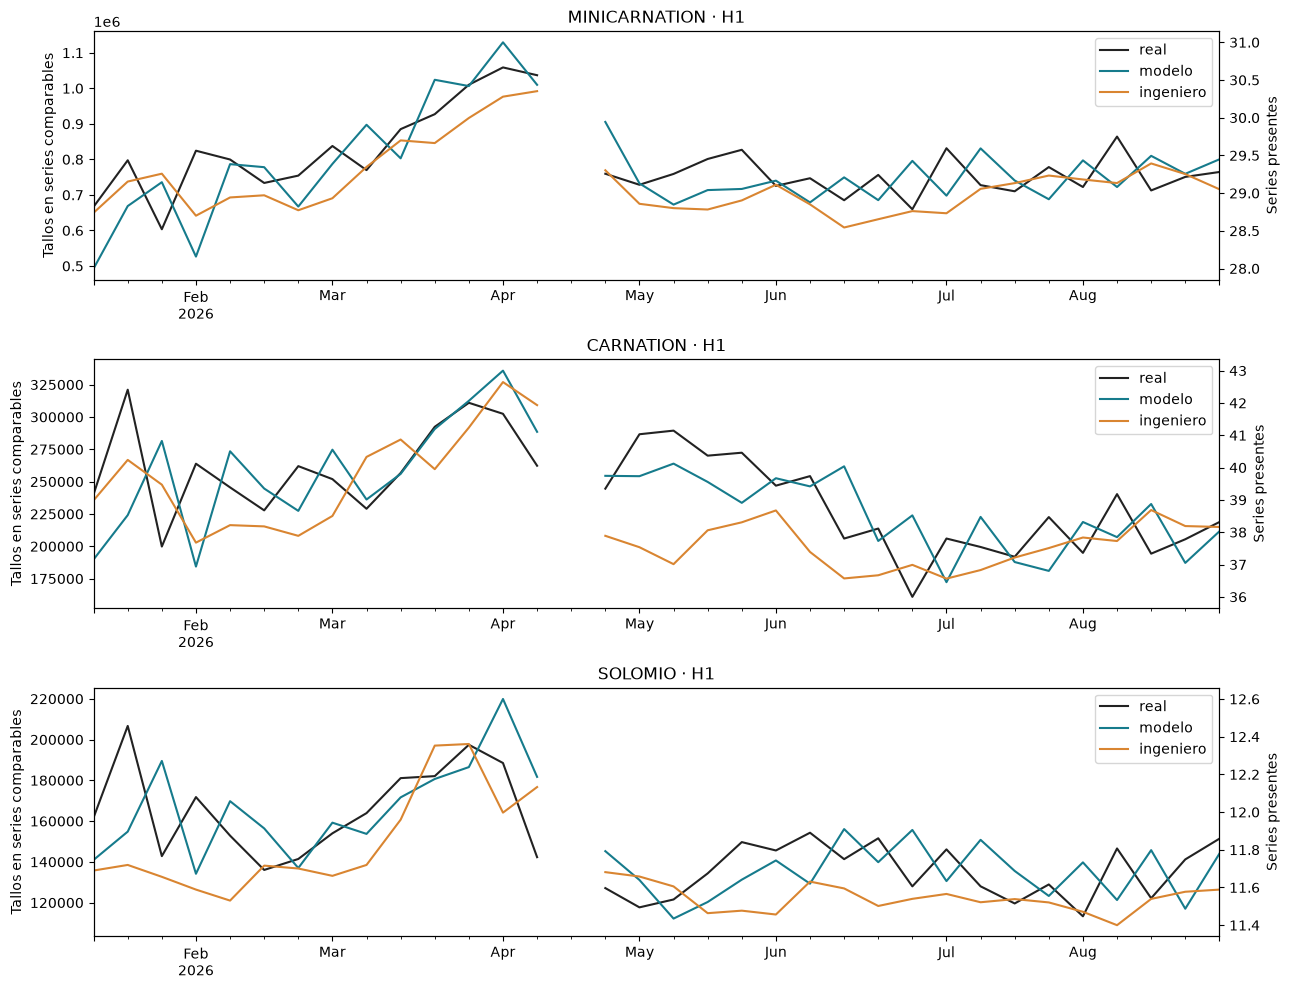

,panel,metodo,producto,error_absoluto,error_top5_casos_pct,error_top3_semanas_pct,semanas,meses,meses_modelo_mejor,meses_modelo_peor
0,H1,Modelo,ACHILLEA,5142.42,27.69,47.93,14,4,2,2
1,H1,Modelo,AMAZON,22938.06,39.08,26.54,33,8,1,7
2,H1,Modelo,BARBATUS,64985.99,11.26,19.19,33,8,6,2
3,H1,Modelo,CARNATION,1509828.99,3.38,17.42,33,8,4,4
4,H1,Modelo,GREEN BALL,36497.44,37.31,24.39,33,8,5,3
5,H1,Modelo,MINICARNATION,3728569.34,4.08,16.85,33,8,3,5
6,H1,Modelo,RAFFINE,415333.40,13.20,18.26,33,8,7,1
7,H1,Modelo,SOLOMIO,741864.56,6.11,18.91,33,8,8,0
8,H1,Modelo,STAR,73524.52,33.56,27.37,33,8,4,4
9,H1,Modelo,STATICE,32449.75,18.16,19.69,30,8,5,3


,finca,producto,color,variedad,origen,semana_objetivo,horizonte,y,Modelo,Ingeniero,ruta,media_4,variabilidad_previa,cambio_real_expost,error_modelo,error_ingeniero,absoluto_modelo,absoluto_ingeniero,exceso_error_modelo
1917,GAITANA,MINICARNATION,ORANGE,UCHUVA,2026-02-02,2026-02-02,1.0,71546,32985.643682,53560.0,Respaldo de producción reciente,46722.25,"Media: 0,25–0,50","Subida: real > 1,5 × media4",-38560.356318,-17986.0,38560.356318,17986.0,20574.356318
1889,GAITANA,MINICARNATION,HOT PINK,LORENZO,2026-02-02,2026-02-02,1.0,64962,32283.213133,41200.0,Respaldo de producción reciente,45722.75,"Media: 0,25–0,50","Dentro de 0,5–1,5 × media4",-32678.786867,-23762.0,32678.786867,23762.0,8916.786867
8059,GAITANA,MINICARNATION,ORANGE,UCHUVA,2026-05-11,2026-05-11,1.0,79168,47923.661950,54500.0,Respaldo de producción reciente,77898.75,"Baja: CV ≤ 0,25","Dentro de 0,5–1,5 × media4",-31244.33805,-24668.0,31244.33805,24668.0,6576.33805
1901,GAITANA,MINICARNATION,LIGHT PINK,ACADEMY,2026-02-02,2026-02-02,1.0,63768,38724.312283,59740.0,Respaldo de producción reciente,43124.75,"Media: 0,25–0,50","Dentro de 0,5–1,5 × media4",-25043.687717,-4028.0,25043.687717,4028.0,21015.687717
8061,GAITANA,MINICARNATION,ORANGE,UCHUVA,2026-05-25,2026-05-25,1.0,88686,64043.125029,67970.0,Respaldo de producción reciente,73938.75,"Baja: CV ≤ 0,25","Dentro de 0,5–1,5 × media4",-24642.874971,-20716.0,24642.874971,20716.0,3926.874971
14649,GAITANA,MINICARNATION,YELLOW,CAESAR,2026-08-10,2026-08-10,1.0,79190,56056.361253,63890.0,Respaldo de producción reciente,52484.50,"Media: 0,25–0,50","Subida: real > 1,5 × media4",-23133.638747,-15300.0,23133.638747,15300.0,7833.638747
208,GAITANA,MINICARNATION,LIGHT PINK,ACADEMY,2026-01-19,2026-01-19,1.0,62307,39392.707481,50000.0,Respaldo de producción reciente,27062.75,"Media: 0,25–0,50","Subida: real > 1,5 × media4",-22914.292519,-12307.0,22914.292519,12307.0,10607.292519
1897,GAITANA,MINICARNATION,LAVENDER,NENUFAR,2026-02-02,2026-02-02,1.0,57121,34589.087985,40170.0,Respaldo de producción reciente,41577.25,"Baja: CV ≤ 0,25","Dentro de 0,5–1,5 × media4",-22531.912015,-16951.0,22531.912015,16951.0,5580.912015
4063,GAITANA,MINICARNATION,HOT PINK,LORENZO,2026-03-23,2026-03-23,1.0,54439,76774.136012,52250.0,Respaldo de producción reciente,53494.25,"Baja: CV ≤ 0,25","Dentro de 0,5–1,5 × media4",22335.136012,-2189.0,22335.136012,2189.0,20146.136012
1933,GAITANA,MINICARNATION,RED,ARAGON,2026-02-02,2026-02-02,1.0,53741,31646.043265,42230.0,Respaldo de producción reciente,40997.00,"Media: 0,25–0,50","Dentro de 0,5–1,5 × media4",-22094.956735,-11511.0,22094.956735,11511.0,10583.956735


In [5]:
for nombre in ['Ruta','Variabilidad','Cambio_expost']:
    print(nombre)
    display(tablas[nombre].loc[lambda t:t.panel.isin(['H1','H1–H5']),niveles[nombre]+['panel','metodo','casos','peso_real_pct','WAPE_pct','sesgo_pct','participacion_error_pct','soporte_bajo']].round(3))
semanas=d.loc[d.horizonte.eq(1)].groupby(['producto','semana_objetivo']).agg(real=('y','sum'),modelo=('Modelo','sum'),ingeniero=('Ingeniero','sum'),series=('variedad','size')).reset_index()
top=comparaciones['Producto'].query("panel == 'H1'").assign(prioridad=lambda t:t.aporte_WAPE_pp_modelo+t.aporte_WAPE_pp_ingeniero).nlargest(3,'prioridad').producto.tolist()
fig,axes=plt.subplots(3,1,figsize=(13,10))
for ax,producto in zip(axes,top):
    z=semanas.loc[semanas.producto.eq(producto)].set_index('semana_objetivo')
    z=z.reindex(pd.date_range(semanas.semana_objetivo.min(),semanas.semana_objetivo.max(),freq='W-MON'))
    z[['real','modelo','ingeniero']].plot(ax=ax,color=['#222222','#167b8c','#d98531'])
    ax.set_title(producto+' · H1');ax.set_ylabel('Tallos en series comparables');ax.set_xlabel('')
    ax2=ax.twinx();ax2.plot(z.index,z.series,color='#888888',linestyle=':',alpha=.5);ax2.set_ylabel('Series presentes')
fig.tight_layout();fig.savefig(FIG/'error_trayectorias_productos_h1.png',dpi=160);plt.show()
concentracion=[]
for p,g in PANELES.items():
    for metodo in METODOS:
        for producto,z in g.groupby('producto'):
            e=(z[metodo]-z.y).abs();por_semana=e.groupby(z.semana_objetivo).sum()
            mensuales=z.assign(ae=e).groupby('mes').apply(lambda x:((x.Modelo-x.y).abs().sum()-(x.Ingeniero-x.y).abs().sum()))
            concentracion.append({'panel':p,'metodo':metodo,'producto':producto,'error_absoluto':e.sum(),'error_top5_casos_pct':100*e.nlargest(5).sum()/e.sum() if e.sum() else 0,'error_top3_semanas_pct':100*por_semana.nlargest(3).sum()/e.sum() if e.sum() else 0,'semanas':len(por_semana),'meses':len(mensuales),'meses_modelo_mejor':int(mensuales.lt(0).sum()),'meses_modelo_peor':int(mensuales.gt(0).sum())})
concentracion=pd.DataFrame(concentracion)
display(concentracion.loc[concentracion.panel.eq('H1')].round(2))
casos=d[KEY+['y','Modelo','Ingeniero','ruta','media_4','variabilidad_previa','cambio_real_expost']].copy()
casos['error_modelo']=casos.Modelo-casos.y;casos['error_ingeniero']=casos.Ingeniero-casos.y
casos['absoluto_modelo']=casos.error_modelo.abs();casos['absoluto_ingeniero']=casos.error_ingeniero.abs()
casos['exceso_error_modelo']=casos.absoluto_modelo-casos.absoluto_ingeniero
display(casos.loc[casos.horizonte.eq(1)].nlargest(15,'absoluto_modelo'))

## 5. Salidas y lectura para el proyecto

Priorizar por aporte absoluto y persistencia, no por un ranking de WAPE sin volumen. Para los productos con más error, revisar las semanas concretas, cambios de producción, identidad y cobertura antes de proponer modelos adicionales. Una variedad pequeña o un episodio aislado no justifican una regla propia.

El Excel contiene el detalle completo, las diferencias emparejadas, el soporte, las semanas críticas y los casos originales. El Markdown de hallazgos facilita actualizar el resumen y el escrito. Ninguna de estas salidas modifica la selección ni el benchmark de 19.

In [6]:
with pd.ExcelWriter(OUT/'diagnostico_origen_error.xlsx') as w:
    globales.to_excel(w,sheet_name='Global',index=False)
    for nombre,t in tablas.items():t.to_excel(w,sheet_name=nombre,index=False)
    for nombre in ['Producto','Color','Variedad']:comparaciones[nombre].to_excel(w,sheet_name='Comparar_'+nombre,index=False)
    concentracion.to_excel(w,sheet_name='Concentracion',index=False)
    semanas.to_excel(w,sheet_name='Trayectorias_H1',index=False)
    casos.to_excel(w,sheet_name='Casos',index=False)
casos.to_parquet(OUT/'casos_error_comparables.parquet',index=False)
def num(x):return f'{x:.2f}'.replace('.',',')
texto='# Origen del error semanal: diagnóstico de 20\n\n'
texto+='Mismos casos estrictos de 19. Aportes en puntos del WAPE total; sesgo positivo significa sobreestimar. Los grupos se ordenan por su aporte, no sólo por WAPE local.\n\n'
for p in ['H1','H1–H5']:
    c=comparaciones['Producto'].query('panel == @p').copy();c['prioridad']=c.aporte_WAPE_pp_modelo+c.aporte_WAPE_pp_ingeniero;c=c.sort_values('prioridad',ascending=False)
    texto+=f'## {p}: productos\n\n| Producto | Casos | WAPE modelo | WAPE ingeniero | Aporte modelo (pp) | Aporte ingeniero (pp) | Sesgo modelo | Sesgo ingeniero |\n| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |\n'
    for r in c.itertuples():texto+=f'| {r.producto} | {r.casos} | {num(r.WAPE_pct_modelo)} % | {num(r.WAPE_pct_ingeniero)} % | {num(r.aporte_WAPE_pp_modelo)} | {num(r.aporte_WAPE_pp_ingeniero)} | {num(r.sesgo_pct_modelo)} % | {num(r.sesgo_pct_ingeniero)} % |\n'
    for m in METODOS:
        t=tablas['Producto'].query('panel == @p and metodo == @m').nlargest(3,'error_absoluto')
        texto+=f'\n{m}: los tres mayores aportes ({", ".join(t.producto)}) concentran {num(t.participacion_error_pct.sum())} % de su error absoluto.\n'
    for nivel in ['Color','Variedad']:
        t=comparaciones[nivel].query('panel == @p').nlargest(5,'aporte_WAPE_pp_modelo')
        texto+=f'\n### {nivel}: mayores aportes del modelo\n\n| Grupo | Casos | WAPE modelo | WAPE ingeniero | Aporte modelo (pp) | Exceso frente al ingeniero (pp) |\n| --- | ---: | ---: | ---: | ---: | ---: |\n'
        for _,r in t.iterrows():texto+=f'| {" / ".join(str(r[k]) for k in niveles[nivel])} | {r.casos} | {num(r.WAPE_pct_modelo)} % | {num(r.WAPE_pct_ingeniero)} % | {num(r.aporte_WAPE_pp_modelo)} | {num(r.exceso_modelo_pp)} |\n'
texto+='\n## Cómo interpretar\n\nLos diagnósticos de ruta, variabilidad y cambio ex post son asociaciones, no causas. Las tablas dentro de producto ayudan a distinguir composición, pero no eliminan confusión. Los cambios ex post usan producción futura conocida sólo al evaluar. La selección de grupos críticos se hace mirando test: cualquier ajuste posterior debe validarse en otro periodo. No se modifica el modelo con este EDA.\n'
(OUT/'hallazgos_origen_error.md').write_text(texto,encoding='utf-8')
print('Descomposiciones verificadas y exportadas a',OUT)

Descomposiciones verificadas y exportadas a C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos_analiticos_proyecto\eda_origen_error


## 6. Tres variedades para examinar el mecanismo del error

Se eligen, descriptivamente en H1, la variedad con mayor error del modelo y las dos de mayor exceso frente al ingeniero, sin repetir identidad. No son tres nuevos modelos ni una selección para recalibrar con test. Se contrastan producción real, ambos estimados y la media de las cuatro semanas conocida al origen. Los picos o cambios pueden sugerir dependencia excesiva de la historia reciente; no acreditan cambios fisiológicos, de clima o de manejo sin evidencia adicional.

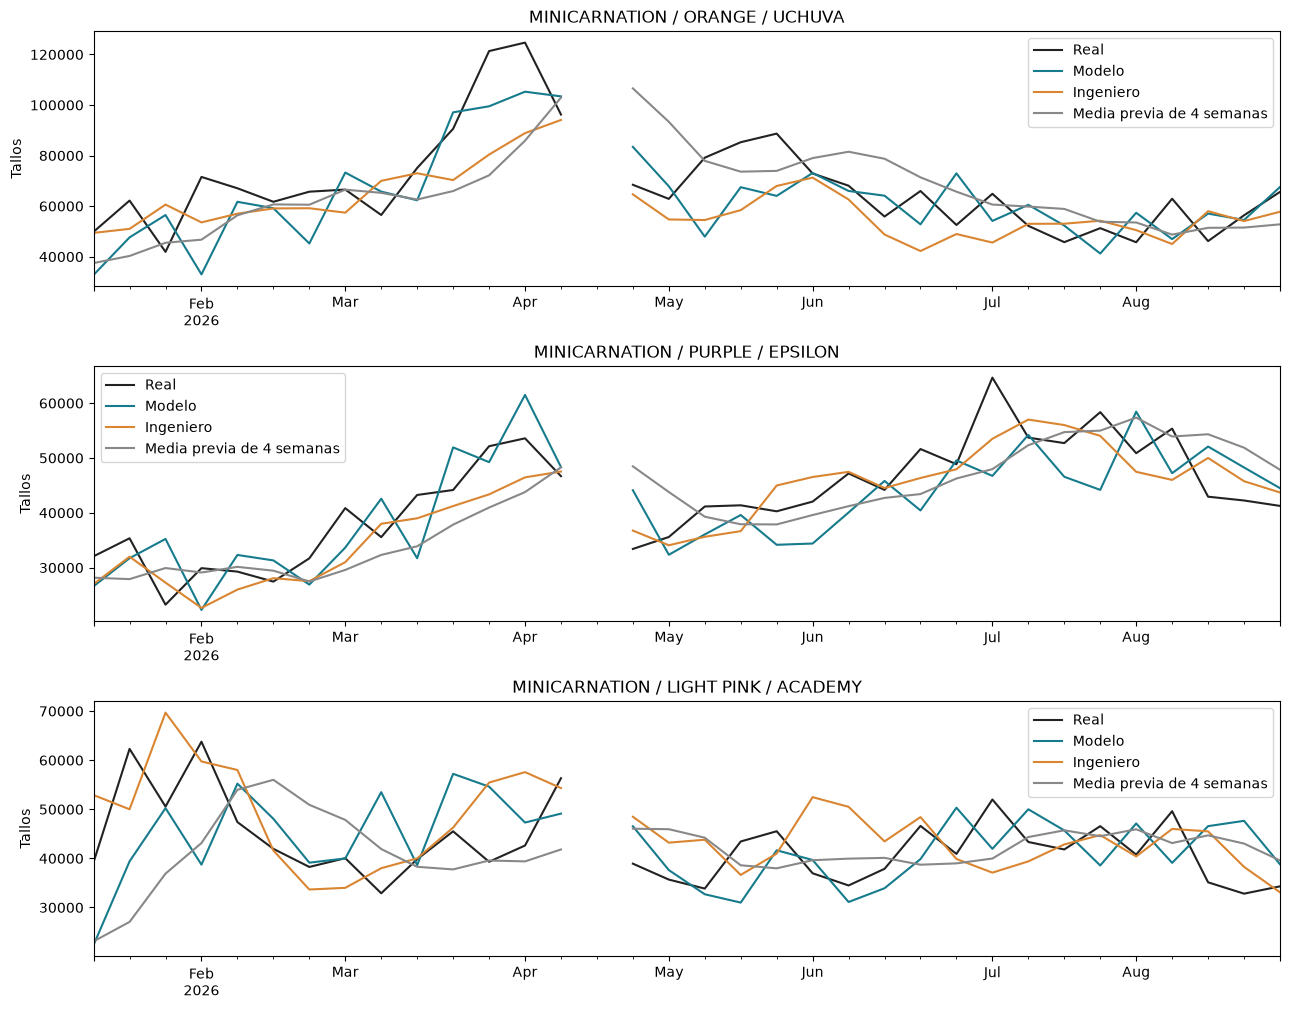

,producto,color,variedad,casos,WAPE_pct_modelo,WAPE_pct_ingeniero,sesgo_pct_modelo,sesgo_pct_ingeniero,aporte_WAPE_pp_modelo,exceso_modelo_pp
79,MINICARNATION,ORANGE,UCHUVA,33,18.404,17.499,-6.589,-12.155,0.957,0.047
82,MINICARNATION,PURPLE,EPSILON,33,15.172,10.114,-3.461,-4.353,0.497,0.166
74,MINICARNATION,LIGHT PINK,ACADEMY,33,19.151,16.364,0.191,6.786,0.627,0.091


,producto,color,variedad,mes,metodo,casos,WAPE_pct,sesgo_pct
0,MINICARNATION,LIGHT PINK,ACADEMY,2026-01,Modelo,3,26.362,-26.362
1,MINICARNATION,LIGHT PINK,ACADEMY,2026-02,Modelo,4,20.833,-5.341
2,MINICARNATION,LIGHT PINK,ACADEMY,2026-03,Modelo,5,24.730,23.461
3,MINICARNATION,LIGHT PINK,ACADEMY,2026-04,Modelo,3,14.145,3.693
4,MINICARNATION,LIGHT PINK,ACADEMY,2026-05,Modelo,4,12.250,-9.807
5,MINICARNATION,LIGHT PINK,ACADEMY,2026-06,Modelo,5,13.306,-0.996
6,MINICARNATION,LIGHT PINK,ACADEMY,2026-07,Modelo,4,15.560,-4.095
7,MINICARNATION,LIGHT PINK,ACADEMY,2026-08,Modelo,5,24.726,13.810
8,MINICARNATION,ORANGE,UCHUVA,2026-01,Modelo,3,30.000,-11.073
9,MINICARNATION,ORANGE,UCHUVA,2026-02,Modelo,4,25.164,-25.164


In [7]:
v=comparaciones['Variedad'].query("panel == 'H1'")
dims=['producto','color','variedad']
foco=pd.concat([v.nlargest(1,'error_absoluto'),v.nlargest(2,'exceso_modelo_pp')]).drop_duplicates(dims)
f=d.loc[d.horizonte.eq(1)].merge(foco[dims],on=dims,validate='many_to_one')
fig,axes=plt.subplots(len(foco),1,figsize=(13,3.4*len(foco)),squeeze=False)
for ax,(_,identidad) in zip(axes[:,0],foco.iterrows()):
    z=f.loc[(f[dims]==identidad[dims]).all(axis=1)].set_index('semana_objetivo').sort_index()
    z=z.reindex(pd.date_range(d.semana_objetivo.min(),d.loc[d.horizonte.eq(1)].semana_objetivo.max(),freq='W-MON'))
    z[['y','Modelo','Ingeniero','media_4']].rename(columns={'y':'Real','media_4':'Media previa de 4 semanas'}).plot(ax=ax,color=['#222222','#167b8c','#d98531','#888888'])
    ax.set_title(' / '.join(identidad[dims]));ax.set_ylabel('Tallos');ax.set_xlabel('')
fig.tight_layout();fig.savefig(FIG/'error_variedades_foco_h1.png',dpi=160);plt.show()
foco_mes=tabla('H1',f,['producto','color','variedad','mes'])
# Este panel es sólo el foco: sus aportes se refieren al volumen del foco, no al de toda la finca.
foco_mes=foco_mes.drop(columns=['aporte_WAPE_pp','aporte_sobre_pp','aporte_sub_pp','peso_real_pct','participacion_error_pct'])
with pd.ExcelWriter(OUT/'diagnostico_origen_error.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as w:
    foco.to_excel(w,sheet_name='Foco_variedades',index=False)
    foco_mes.to_excel(w,sheet_name='Foco_mes',index=False)
    f[KEY+['y','Modelo','Ingeniero','media_4','ruta','cambio_real_expost']].to_excel(w,sheet_name='Foco_semanas',index=False)
display(foco[dims+['casos','WAPE_pct_modelo','WAPE_pct_ingeniero','sesgo_pct_modelo','sesgo_pct_ingeniero','aporte_WAPE_pp_modelo','exceso_modelo_pp']].round(3))
display(foco_mes[dims+['mes','metodo','casos','WAPE_pct','sesgo_pct']].round(3))

## 7. Lectura de esta ejecución (panel 2026)

En H1, MINICARNATION representa 60,34 % del volumen y 55,23 % del error absoluto del modelo; CARNATION añade 22,36 %. Juntos concentran 77,59 % del error del modelo. MINICARNATION también domina el error del ingeniero (51,31 %). Su prioridad se explica sobre todo por escala: el WAPE del modelo en MINICARNATION es 14,33 %, inferior al 18,91 % de CARNATION. No significa que sea el producto de peor tasa.

La mayor parte de la ventaja en H1 procede de RAFFINE y SOLOMIO: reducen respectivamente 0,58 y 0,41 puntos del WAPE total, aproximadamente 69,11 % de la ventaja neta frente al ingeniero. MINICARNATION mejora poco en el agregado y el modelo gana allí sólo 3 de 8 meses. Sus tres semanas de mayor error concentran 16,85 % de su error: no se explica todo por un episodio aislado. En el extremo opuesto, ACHILLEA tiene WAPE 380,92 %, pero menos de 0,01 % del volumen y apenas 0,01 puntos del WAPE total. Requiere revisar sus casos, pero priorizar sólo ese porcentaje ocultaría los grupos de mayor impacto.

En horizontes largos aparece un problema distinto. CARNATION pasa de WAPE 18,91 % en H1 a 26,87 % en H5; el ingeniero obtiene 23,22 % en H5. Allí CARNATION aporta 0,67 puntos a la desventaja global del modelo. Esto orienta a revisar la anticipación y los cambios de producción en ese producto, sin dar por demostrada su causa.

Dentro de MINICARNATION, ORANGE, HOT PINK y LIGHT PINK son los colores con mayor aporte al error H1 de ambos métodos. En el ingeniero, ORANGE tiene sesgo de -12,67 %, frente a -5,36 % del modelo. Sus variedades de mayor error son UCHUVA, LORENZO y NENUFAR. UCHUVA también es la variedad de mayor error del modelo (0,96 puntos del WAPE total). EPSILON aporta la mayor desventaja por variedad: WAPE 15,17 % frente a 10,11 % del ingeniero, diferencia que añade 0,17 puntos al WAPE total. Son criterios distintos: mayor error propio y mayor oportunidad frente al benchmark.

ACADEMY ilustra por qué el sesgo pequeño no basta: sesgo del modelo 0,19 %, pero WAPE 19,15 %, frente a 16,36 % del ingeniero. En H1 agregado, las sobreestimaciones del modelo aportan 7,21 puntos y las subestimaciones 8,45: se compensan en el sesgo de -1,23 %, pero se suman en el WAPE de 15,66 %. Corregir sólo el nivel promedio no resolvería esos errores de dinámica temporal.

Las subidas fuertes —real superior a 1,5 veces la media de cuatro semanas— presentan WAPE 28,12 % y sesgo -27,29 % en el modelo, frente a 26,78 % de WAPE del ingeniero. El modelo queda corto en esos episodios. Sin embargo, 89,39 % de su error H1 ocurre en casos dentro de 0,5–1,5 veces la media: no todo el problema son picos extremos. Esta clasificación usa el real conocido después y sólo sirve para diagnosticar.

La variabilidad previa moderada también identifica dificultad: en CARNATION, WAPE del modelo 26,32 % frente a 17,41 % con baja variabilidad; en MINICARNATION, 21,94 % frente a 13,81 %. Son asociaciones dentro de producto, no efectos causales; los casos de variabilidad alta tienen poco soporte. Tampoco se puede culpar automáticamente a la falta de curva: en MINICARNATION, los 66 casos con teoría completa tienen menor WAPE (11,78 %) que los 913 con respaldo (14,44 %), pero son poblaciones distintas. El Excel conserva esas comparaciones también para el ingeniero.

La revisión práctica debe concentrarse primero en MINICARNATION por volumen y en CARNATION H3–H5 por desventaja de anticipación; después en las semanas de UCHUVA, EPSILON y ACADEMY y sus referencias de producción previa. Las trayectorias muestran picos, alternancia de sobre/subestimaciones y huecos de comparación sin inventar ceros. Son hipótesis de seguimiento temporal y cobertura, no diagnósticos agronómicos ni evidencia de errores de registro. Antes de cambiar el modelo conviene contrastar esos episodios con información operativa; cualquier ajuste posterior necesita evaluación temporal nueva.

Esta interpretación corresponde a los resultados guardados. Si cambian los datos, revisar la redacción después de volver a ejecutar las tablas.